Aantal gevonden brede Doppler-dalen: 1


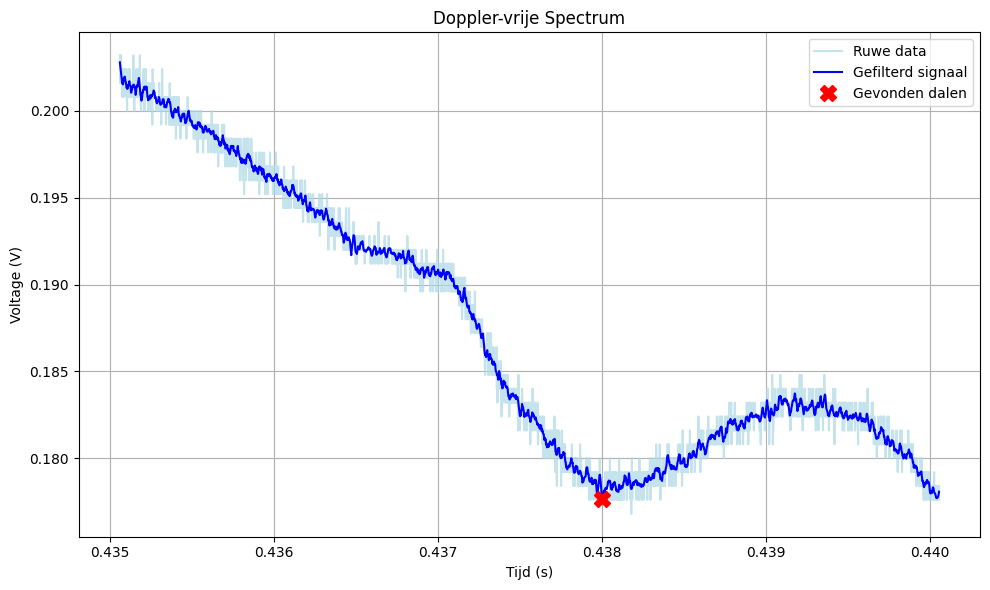


Tijdstippen van de gevonden dalen (s):
Dal 1: 0.438002 s


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

file_ch1 = 's1.CSV'

df_ch1 = pd.read_csv(file_ch1, header=None, usecols=[3, 4], names=['Tijd', 'Voltage'])


tijd = df_ch1['Tijd'].values
signaal = df_ch1['Voltage'].values


signaal_smoothed = savgol_filter(signaal, window_length=15, polyorder=3)


inv_signaal = -signaal_smoothed


pieken_indices, eigenschappen = find_peaks(inv_signaal, prominence=0.002, width=5)

tijd_dalen = tijd[pieken_indices]
voltage_dalen = signaal_smoothed[pieken_indices]

print(f"Aantal gevonden brede Doppler-dalen: {len(pieken_indices)}")

plt.figure(figsize=(10, 6))

plt.plot(tijd, signaal, label='Ruwe data', color='lightblue', alpha=0.7)
plt.plot(tijd, signaal_smoothed, label='Gefilterd signaal', color='blue')
plt.plot(tijd_dalen, voltage_dalen, 'X', color='red', markersize=12, label='Gevonden dalen')

plt.title('Doppler-vrije Spectrum')
plt.xlabel('Tijd (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True)
plt.tight_layout()


plt.show()


print("\nTijdstippen van de gevonden dalen (s):")
for i, t in enumerate(tijd_dalen):
    print(f"Dal {i + 1}: {t:.6f} s")

Lorentz Fit Resultaten
Amplitude (a) : -0.051638 ± 0.000263 V
Centrum (x0)  : 0.531892 ± 0.000001 s
Breedte (gam) : -0.007408 ± 0.000028 s
Offset (c)    : 0.181562 ± 0.000267 V
R-squared     : 0.998500


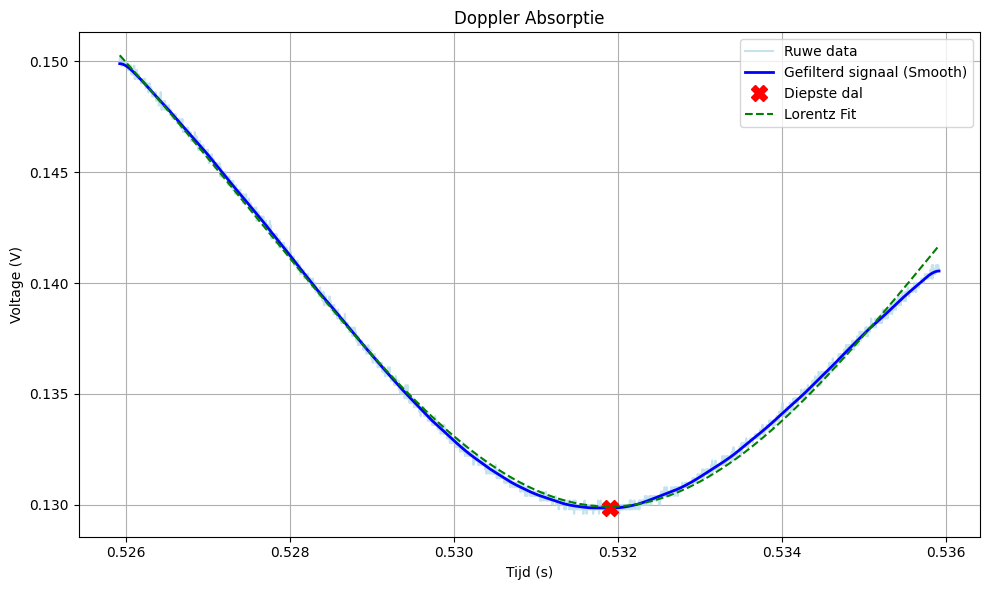

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit

df_vrij = pd.read_csv('dff.CSV', header=None, usecols=[3, 4], names=['Tijd', 'Voltage'])

tijd = df_vrij['Tijd'].values
signaal = df_vrij['Voltage'].values

signaal_smoothed = gaussian_filter1d(signaal, sigma=20)

inv_signaal = -signaal_smoothed
pieken_indices, _ = find_peaks(inv_signaal, prominence=0.001, width=20)

if len(pieken_indices) > 0:
    diepste_dal_index = pieken_indices[np.argmin(signaal_smoothed[pieken_indices])]
    tijd_dal = tijd[diepste_dal_index]
    voltage_dal = signaal_smoothed[diepste_dal_index]
else:
    tijd_dal, voltage_dal = [], []

def lorentz_dip(x, a, x0, gamma, c):
    return a * (gamma**2 / ((x - x0)**2 + gamma**2)) + c

if len(pieken_indices) > 0:
    p0 = [voltage_dal - np.max(signaal_smoothed), tijd_dal, 0.01, np.max(signaal_smoothed)]
    popt, pcov = curve_fit(lorentz_dip, tijd, signaal_smoothed, p0=p0, maxfev=10000)
    fit_data = lorentz_dip(tijd, *popt)
    
    perr = np.sqrt(np.diag(pcov))
    
    ss_res = np.sum((signaal_smoothed - fit_data)**2)
    ss_tot = np.sum((signaal_smoothed - np.mean(signaal_smoothed))**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    print("Lorentz Fit Resultaten")
    print(f"Amplitude (a) : {popt[0]:.6f} ± {perr[0]:.6f} V")
    print(f"Centrum (x0)  : {popt[1]:.6f} ± {perr[1]:.6f} s")
    print(f"Breedte (gam) : {popt[2]:.6f} ± {perr[2]:.6f} s")
    print(f"Offset (c)    : {popt[3]:.6f} ± {perr[3]:.6f} V")
    print(f"R-squared     : {r_squared:.6f}") 

plt.figure(figsize=(10, 6))
plt.plot(tijd, signaal, label='Ruwe data', color='lightblue', alpha=0.7)
plt.plot(tijd, signaal_smoothed, label='Gefilterd signaal (Smooth)', color='blue', linewidth=2)

if len(pieken_indices) > 0:
    plt.plot(tijd_dal, voltage_dal, 'X', color='red', markersize=12, label='Diepste dal')
    plt.plot(tijd, fit_data, label='Lorentz Fit', color='green', linestyle='--')

plt.title('Doppler Absorptie')
plt.xlabel('Tijd (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

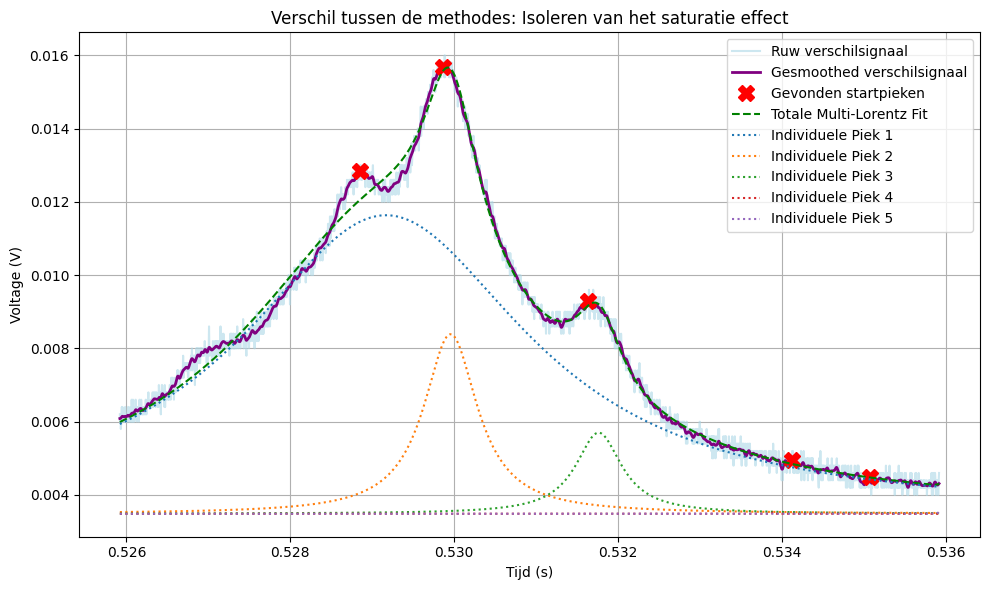

Aantal gevonden saturatiepieken: 5

R-squared van de fit: 0.995518

Multi-Lorentz Fit Resultaten
Piek 1:
  Tijdstip (ruw) : 0.528852 s
  Amplitude (a)  : 0.008148 ± 0.000053 V
  Centrum (fit)  : 0.529168 ± 0.000011 s
  Breedte (gam)  : 0.002129 ± 0.000012 s
Piek 2:
  Tijdstip (ruw) : 0.529864 s
  Amplitude (a)  : 0.004901 ± 0.000052 V
  Centrum (fit)  : 0.529955 ± 0.000002 s
  Breedte (gam)  : 0.000400 ± 0.000007 s
Piek 3:
  Tijdstip (ruw) : 0.531636 s
  Amplitude (a)  : 0.002214 ± 0.000032 V
  Centrum (fit)  : 0.531762 ± 0.000004 s
  Breedte (gam)  : 0.000342 ± 0.000010 s
Piek 4:
  Tijdstip (ruw) : 0.534124 s
  Amplitude (a)  : 0.000040 ± 0.000152 V
  Centrum (fit)  : 0.533889 ± 0.000038 s
  Breedte (gam)  : 0.000010 ± 0.000055 s
Piek 5:
  Tijdstip (ruw) : 0.535068 s
  Amplitude (a)  : 0.000360 ± 0.102874 V
  Centrum (fit)  : 0.535946 ± 0.001057 s
  Breedte (gam)  : 0.000013 ± 0.001653 s

Offset (c)       : 0.003486 ± 0.000021 V


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit

df_doppler = pd.read_csv('sff.CSV', header=None, usecols=[3, 4], names=['Tijd', 'Voltage'])
df_vrij = pd.read_csv('dff.CSV', header=None, usecols=[3, 4], names=['Tijd', 'Voltage'])

tijd = df_doppler['Tijd'].values
signaal_doppler = df_doppler['Voltage'].values
signaal_vrij = df_vrij['Voltage'].values

verschil_ruw = signaal_doppler - signaal_vrij

verschil_smoothed = gaussian_filter1d(verschil_ruw, sigma=3)

pieken_indices, _ = find_peaks(verschil_smoothed, prominence=0.0002)

tijd_pieken = tijd[pieken_indices]
voltage_pieken = verschil_smoothed[pieken_indices]

def multi_lorentz(x, *params):
    y = np.zeros_like(x, dtype=float)
    for i in range(0, len(params)-1, 3):
        a = params[i]
        x0 = params[i+1]
        gamma = params[i+2]
        y += a * (gamma**2 / ((x - x0)**2 + gamma**2))
    y += params[-1]
    return y

if len(pieken_indices) > 0:
    p0 = []
    lower_bounds = []
    upper_bounds = []
    for i in range(len(pieken_indices)):
        p0.extend([voltage_pieken[i], tijd_pieken[i], 0.0005])
        lower_bounds.extend([0, tijd_pieken[i] - 0.002, 0.00001])
        upper_bounds.extend([np.max(verschil_smoothed) * 1.5, tijd_pieken[i] + 0.002, 0.01])
    p0.append(0.0)
    lower_bounds.append(-np.max(verschil_smoothed))
    upper_bounds.append(np.max(verschil_smoothed))
    
    popt, pcov = curve_fit(multi_lorentz, tijd, verschil_smoothed, p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=100000)
    fit_data = multi_lorentz(tijd, *popt)
    
    perr = np.sqrt(np.diag(pcov))
    
    ss_res = np.sum((verschil_smoothed - fit_data)**2)
    ss_tot = np.sum((verschil_smoothed - np.mean(verschil_smoothed))**2)
    r_squared = 1 - (ss_res / ss_tot)

plt.figure(figsize=(10, 6))

plt.plot(tijd, verschil_ruw, label='Ruw verschilsignaal', color='lightblue', alpha=0.6)
plt.plot(tijd, verschil_smoothed, label='Gesmoothed verschilsignaal', color='purple', linewidth=2)

if len(pieken_indices) > 0:
    plt.plot(tijd_pieken, voltage_pieken, 'X', color='red', markersize=12, label='Gevonden startpieken')
    plt.plot(tijd, fit_data, label='Totale Multi-Lorentz Fit', color='green', linestyle='--')
    
    for i in range(len(pieken_indices)):
        idx = i * 3
        a = popt[idx]
        x0 = popt[idx+1]
        gamma = popt[idx+2]
        offset = popt[-1]
        
        y_indiv = a * (gamma**2 / ((tijd - x0)**2 + gamma**2)) + offset
        plt.plot(tijd, y_indiv, linestyle=':', label=f'Individuele Piek {i+1}')

plt.title('Verschil tussen de methodes: Isoleren van het saturatie effect')
plt.xlabel('Tijd (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

if len(pieken_indices) > 0:
    print(f"Aantal gevonden saturatiepieken: {len(pieken_indices)}\n")
    print(f"R-squared van de fit: {r_squared:.6f}\n")
    print("Multi-Lorentz Fit Resultaten")
    for i in range(len(pieken_indices)):
        idx = i * 3
        print(f"Piek {i + 1}:")
        print(f"  Tijdstip (ruw) : {tijd_pieken[i]:.6f} s")
        print(f"  Amplitude (a)  : {popt[idx]:.6f} ± {perr[idx]:.6f} V")
        print(f"  Centrum (fit)  : {popt[idx+1]:.6f} ± {perr[idx+1]:.6f} s")
        print(f"  Breedte (gam)  : {popt[idx+2]:.6f} ± {perr[idx+2]:.6f} s")
    print(f"\nOffset (c)       : {popt[-1]:.6f} ± {perr[-1]:.6f} V")

else:
    print("Geen duidelijke piek gevonden, probeer de prominence aan te passen.")